# **End-of-distribution imputation strategy On Normal Distribued data** 

In [ ]:
import pandas as pd
import numpy as np
import seaborn  as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [360]:
df = pd.read_csv('train.csv' , usecols=['Age' , 'Fare' , 'Survived'])

In [361]:
x = df.drop(columns=['Survived'])
y = df['Survived']

In [362]:
pt1 = PowerTransformer()
x_norm = pt1.fit_transform(x)

In [363]:
x_norm= pd.DataFrame(x_norm , columns=pt1.get_feature_names_out())

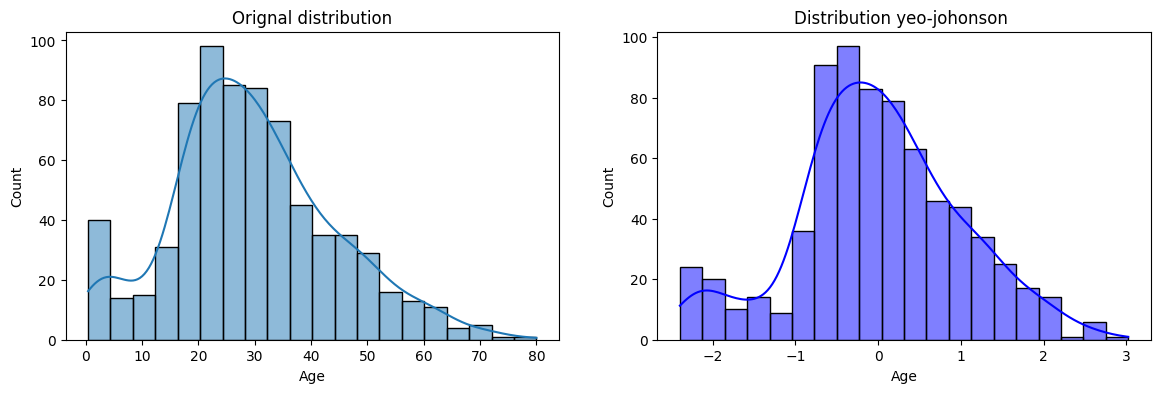

In [364]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(x['Age'] , kde = True )
plt.title('Orignal distribution')

plt.subplot(122)
sns.histplot(x_norm['Age'] , kde = True , color='blue')
plt.title('Distribution yeo-johonson ')

plt.show()

In [365]:
x_norm.isnull().sum()

Age     177
Fare      0
dtype: int64

In [366]:
x_train ,x_test, y_train,y_test = train_test_split(x_norm ,y ,test_size=0.2 , random_state=2)

In [367]:
x_train['Age_mean_Upper'] = x_train['Age'].fillna( (x_train['Age'].mean()) + (3*x_train['Age'].std()))

In [368]:
x_train['Age_mean_Lower'] = x_train['Age'].fillna( (x_train['Age'].mean()) - (3*x_train['Age'].std()))

In [369]:
x_train

,Age,Fare,Age_mean_Upper,Age_mean_Lower
30,0.731193,0.451609,0.731193,0.731193
10,-1.971897,-0.045488,-1.971897,-1.971897
873,1.161694,-0.662914,1.161694,1.161694
182,-1.496407,0.571395,-1.496407,-1.496407
876,-0.617975,-0.573000,-0.617975,-0.617975
...,...,...,...,...
534,0.083431,-0.701150,0.083431,0.083431
584,NaN,-0.695393,2.964690,-2.948960
493,2.537197,1.002303,2.537197,2.537197
527,NaN,2.313273,2.964690,-2.948960


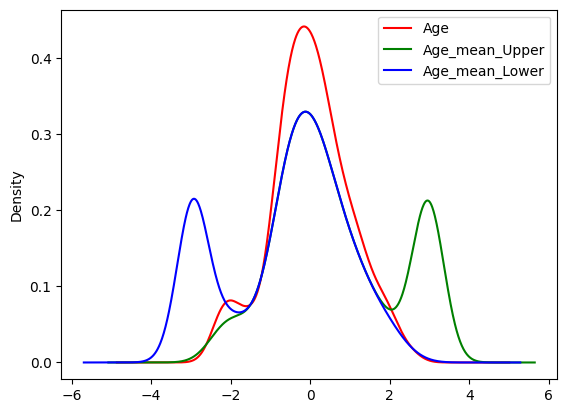

In [370]:
fig = plt.figure()
ax = fig.add_subplot(111)

x_train['Age'].plot(kind='kde', ax=ax ,color='red')
x_train['Age_mean_Upper'].plot(kind='kde' , ax=ax , color='green')
x_train['Age_mean_Lower'].plot(kind='kde' , ax=ax , color='blue')

lines , label= ax.get_legend_handles_labels()
ax.legend(lines, label ,loc='best')
plt.show()

# **Using Sklearn**

In [371]:
x_train ,x_test, y_train,y_test = train_test_split(x_norm ,y ,test_size=0.2 , random_state=2)

In [372]:
mean_Age = x_train['Age'].mean()
std = x_train['Age'].std()

In [373]:
value = mean_Age + 3*std
value2 = mean_Age - 3*std

In [374]:
Upper = SimpleImputer(
    strategy='constant',
    fill_value=value
)
Lower =  SimpleImputer(
    strategy='constant',
    fill_value=value2
)


In [375]:
trf1 = ColumnTransformer([
    ('Upper_val_Fill' , Upper , ['Age']),
    ('Lower_val_Fill' , Lower , ['Age']),
], remainder='passthrough')

In [376]:
x_train_impute = trf1.fit_transform(x_train)

In [377]:
x_train_impute  = pd.DataFrame(x_train_impute , columns=trf1.get_feature_names_out())

In [378]:
x_train_impute

,Upper_val_Fill__Age,Lower_val_Fill__Age,remainder__Fare
0,0.731193,0.731193,0.451609
1,-1.971897,-1.971897,-0.045488
2,1.161694,1.161694,-0.662914
3,-1.496407,-1.496407,0.571395
4,-0.617975,-0.617975,-0.573000
...,...,...,...
707,0.083431,0.083431,-0.701150
708,2.964690,-2.948960,-0.695393
709,2.537197,2.537197,1.002303
710,2.964690,-2.948960,2.313273


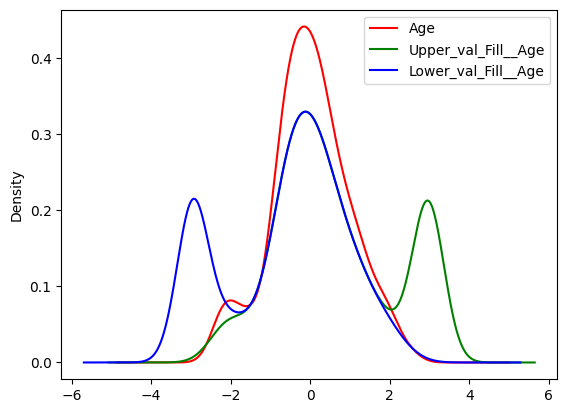

In [379]:
fig = plt.figure()
ax = fig.add_subplot(111)

x_train['Age'].plot(kind='kde', ax=ax ,color='red')
x_train_impute['Upper_val_Fill__Age'].plot(kind='kde' , ax=ax , color='green')
x_train_impute['Lower_val_Fill__Age'].plot(kind='kde' , ax=ax , color='blue')

lines , label= ax.get_legend_handles_labels()
ax.legend(lines, label ,loc='best')
plt.show()